# CASE B : Physics only (dt=0.05)



 PHASE 1: Physics-only 
1 phys 1.2874033793766753
100 phys 0.0012609818508787824
200 phys 0.0005330029853171963
300 phys 0.0007819992505880071
400 phys 0.00039409354484654086
500 phys 0.00034133465398104173
600 phys 0.0002318828176984181
700 phys 0.0005479852393722568
800 phys 0.0003018089514841466
900 phys 0.0007424590771236752
1000 phys 0.00023793067387329166
1100 phys 0.0002308347488155092
1200 phys 0.00022196645393997256

 TEST & DIAGNOSTICS (Physics-only + rollout) 

--- sin(x) ---
[test] sin(x)       | Residual : L∞=7.141e-02 | Mean=1.785e-02


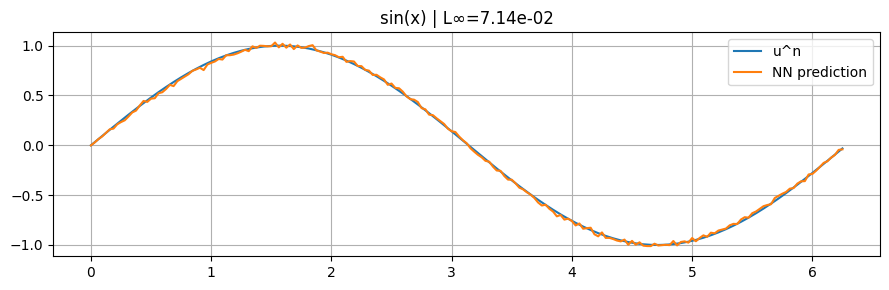

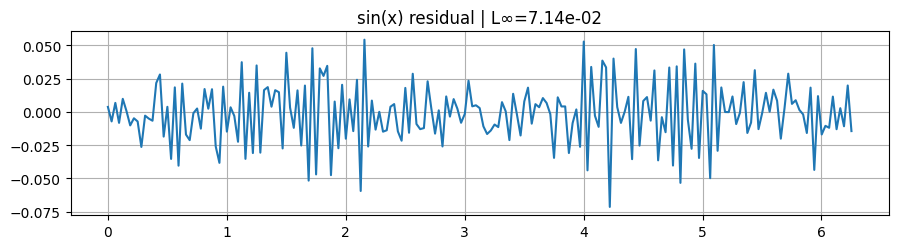

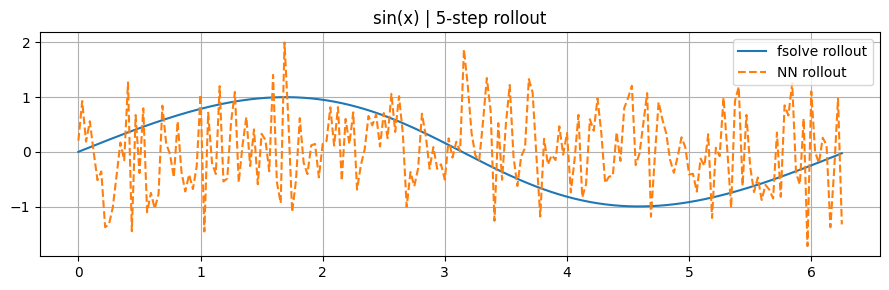


--- cos(14*x) ---
[test] cos(14*x)    | Residual : L∞=3.093e-02 | Mean=6.582e-03


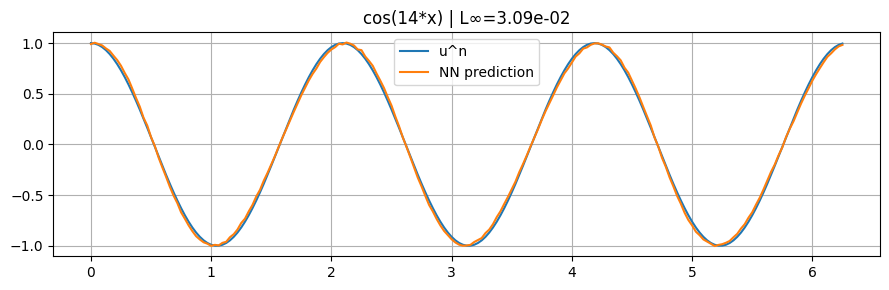

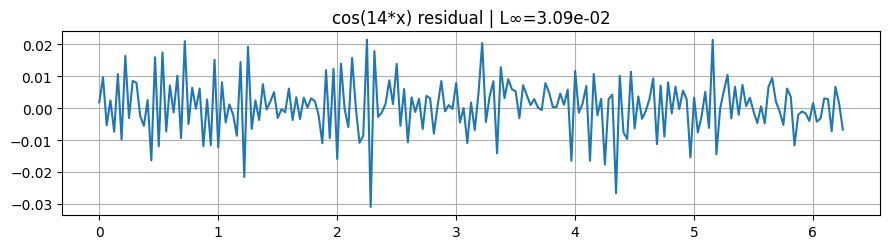

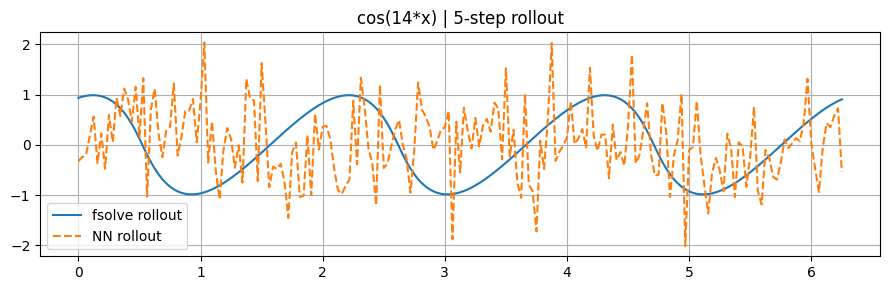


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual : L∞=7.781e-02 | Mean=1.739e-02


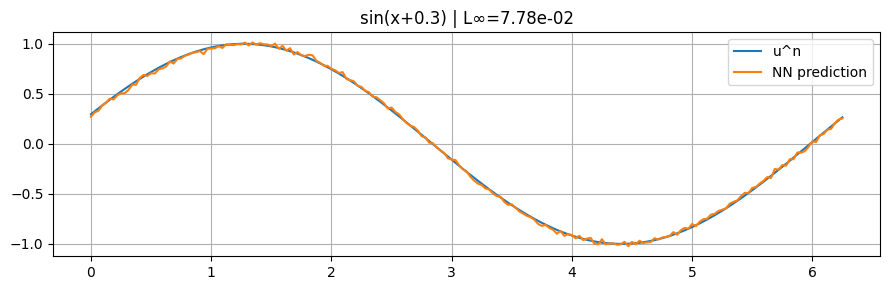

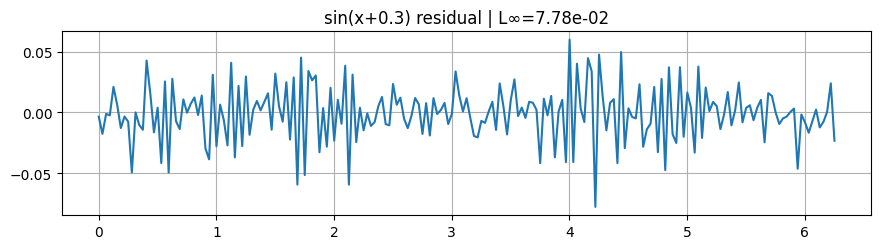

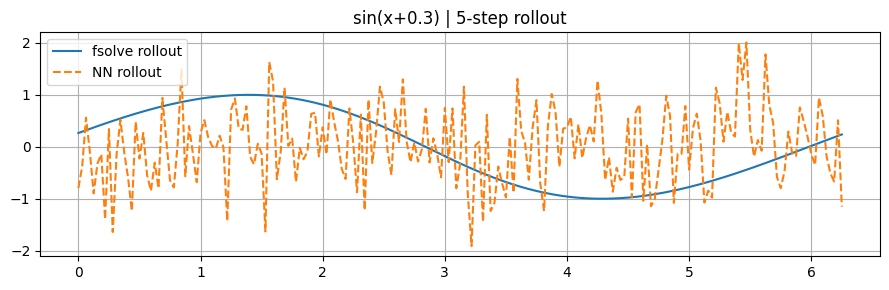


--- sin^2(x) ---
[test] sin^2(x)     | Residual : L∞=3.506e-02 | Mean=6.416e-03


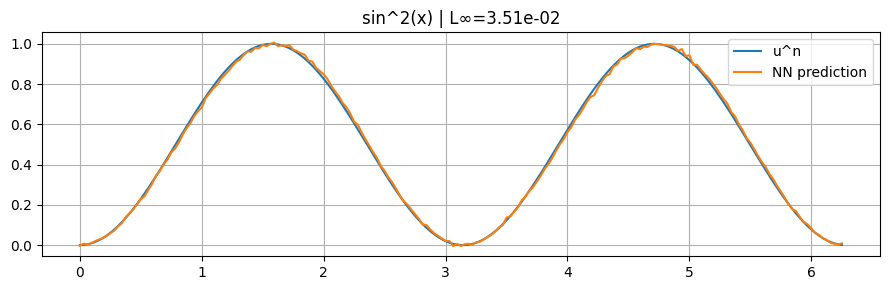

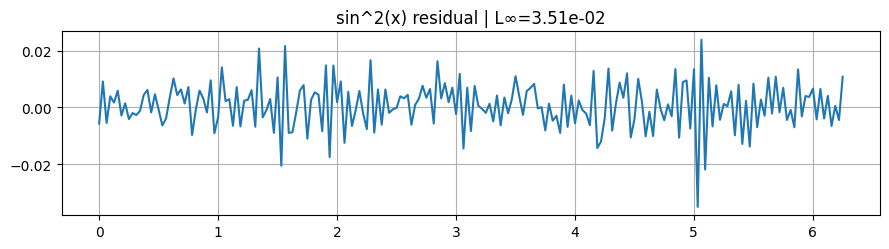

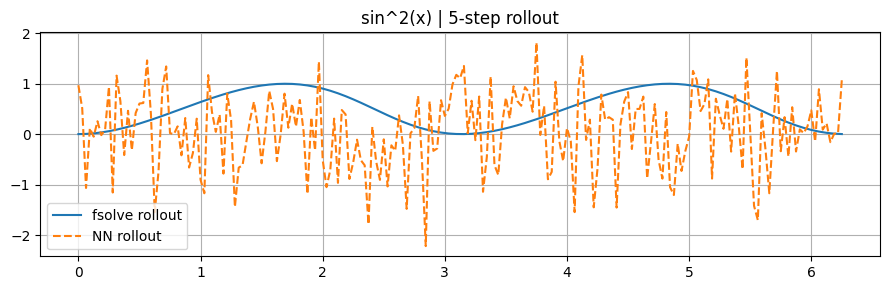


--- cos^3(x) ---
[test] cos^3(x)     | Residual : L∞=3.790e-02 | Mean=7.672e-03


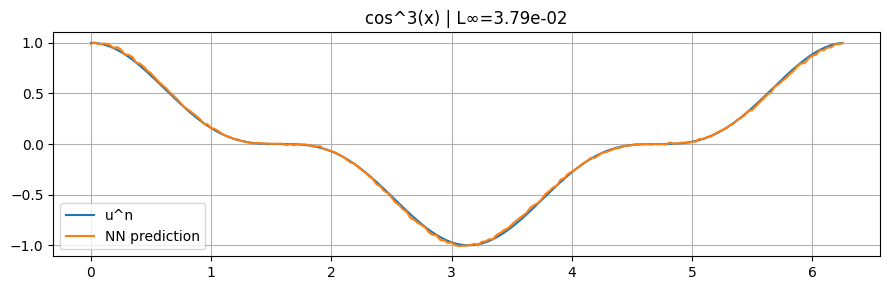

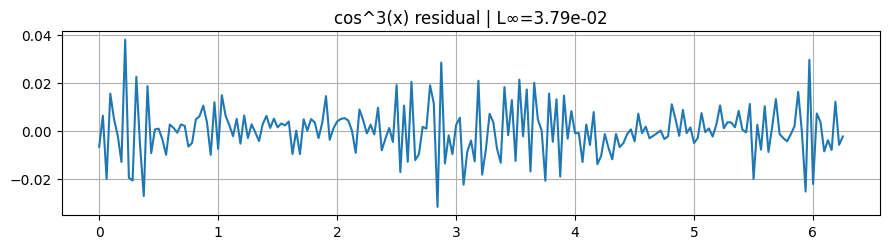

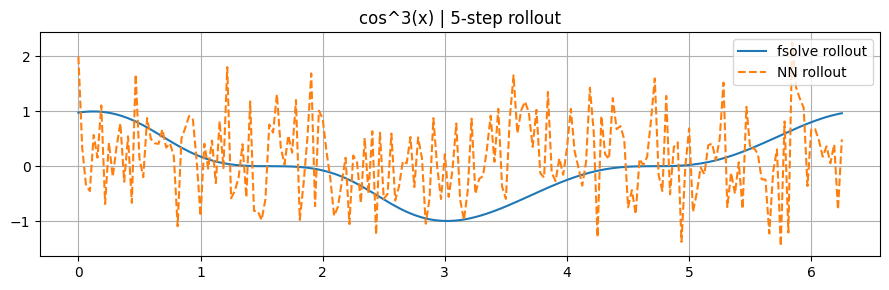


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual : L∞=2.810e-02 | Mean=7.217e-03


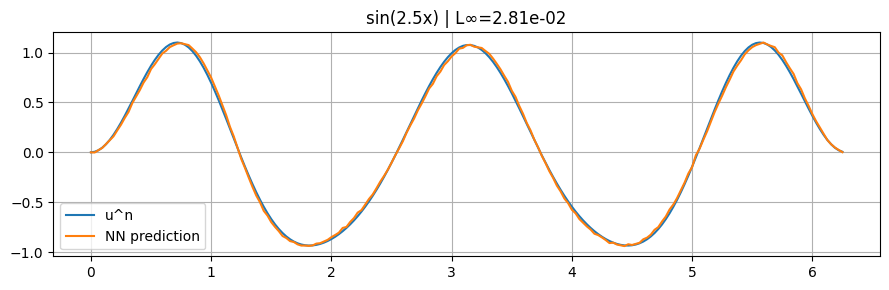

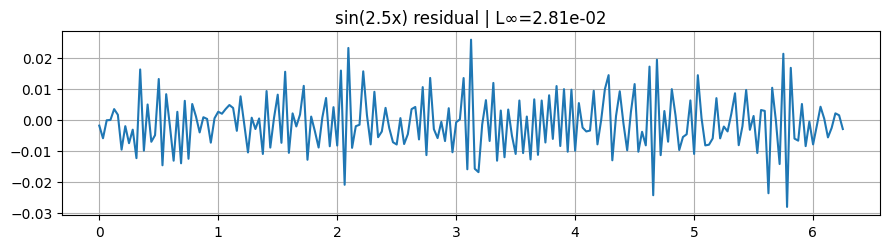

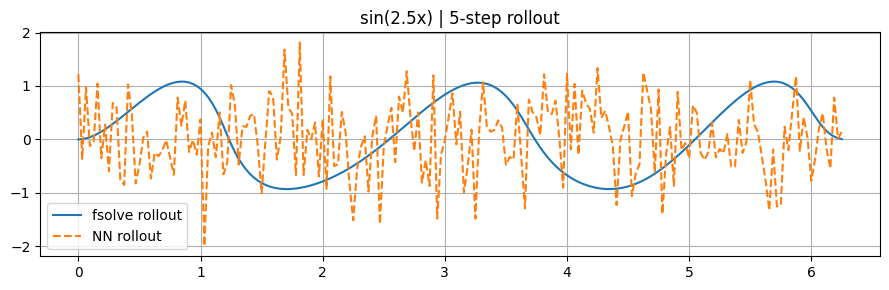


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual : L∞=4.770e-02 | Mean=1.170e-02


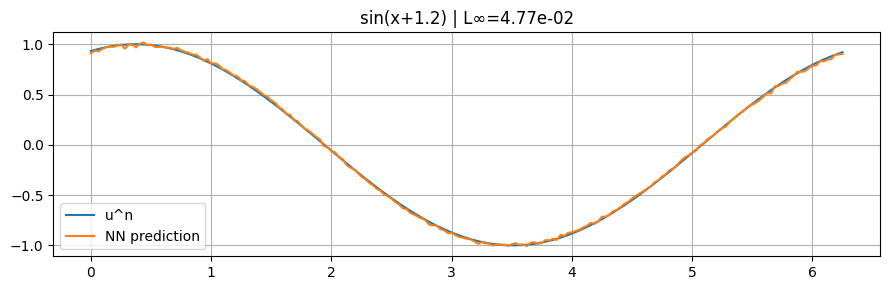

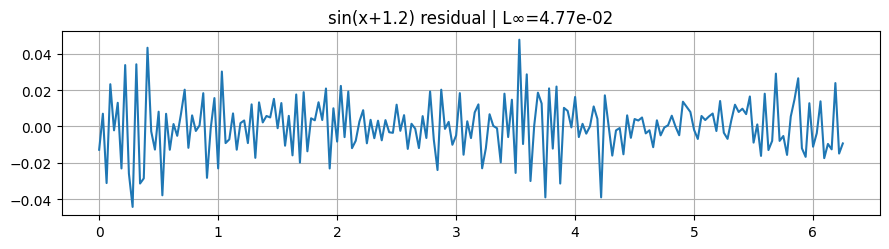

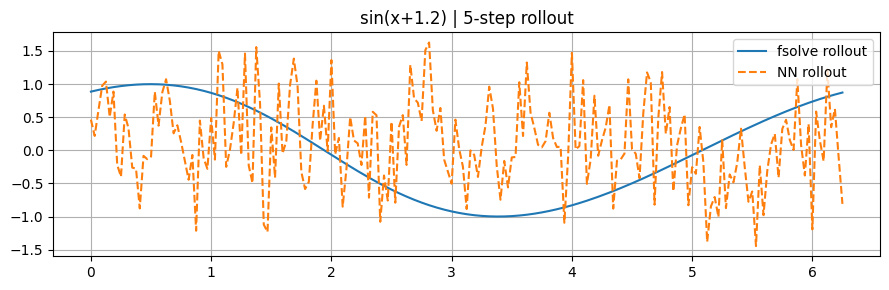


DONE.


In [1]:
import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

# CONFIG
TF64 = True
NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

EPOCHS       = 1200
LR           = 2e-5

SUP_WEIGHT   = 0.0
PHYS_WEIGHT  = 0.1 / DT   # FIX 1

BETA_L2      = 1e-6
GRAD_CLIP    = 0.5
PATIENCE     = 800

USE_LBFGS        = True
LBFGS_MAXITER    = 300
LBFGS_FTOL       = 1e-10

OUT_DIR   = "pinn_caseB_phys_only"
os.makedirs(OUT_DIR, exist_ok=True)
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "nn_caseB.weights.h5")
DATA_FILE    = os.path.join(OUT_DIR, "train_pairs_caseB_v2.npz")  # FIX 2

if TF64:
    tf.keras.backend.set_floatx('float64')

np.random.seed(42); tf.random.set_seed(42); random.seed(42)

# Spectral differentiation

def generate_D_matrix(Nx, L):
    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)
    I = np.eye(Nx)
    return np.fft.ifft(k[:, None]*np.fft.fft(I, axis=0), axis=0).real

D_np = generate_D_matrix(NX_FINE, L)
D_tf = tf.constant(D_np, dtype=tf.float64)

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):
    y_sq = tf.square(y)
    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))
    return y - u + 0.25*DT*dy_dx

# grids
x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE,   endpoint=False)

def fourier_interpolate(u_coarse, Nc, Nf):
    Uc = np.fft.fftshift(np.fft.fft(u_coarse))
    pad = Nf - Nc
    Uc = np.pad(Uc, (pad//2, pad-pad//2))
    return (np.fft.ifft(np.fft.ifftshift(Uc))*Nf/Nc).real

# fsolve

def compute_y1_fsolve(un):
    def F(y): return y - un + 0.25*DT*(D_np @ (y**2))
    def J(y): return np.eye(len(un)) + 0.5*DT*(D_np @ np.diag(y))
    y,_ ,_,_=fsolve(F,un,fprime=J,full_output=True)
    return y


# Training Functions
def make_rich_family():
    fns = []
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]

    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns


train_fns = make_rich_family()

# DATA

if os.path.exists(DATA_FILE):
    d=np.load(DATA_FILE)
    un_train=d["un"]; y1_train=d["y1"]
else:
    U=[]; Y=[]
    for _,fn in train_fns:
        uc=fn(x_coarse)
        uf=fourier_interpolate(uc,NX_COARSE,NX_FINE)
        U.append(uf); Y.append(compute_y1_fsolve(uf))
    un_train=np.array(U)
    y1_train=np.array(Y)
    np.savez(DATA_FILE,un=un_train,y1=y1_train)

# FEATURES

def build_features(U):
    mag=np.abs(np.fft.fft(U,axis=-1))[:,:NX_FINE//2+1]
    mag = 0.2 * mag
    return np.concatenate([U,mag],axis=-1)

X_raw=build_features(un_train)
feat_mean=X_raw.mean(0)
feat_std=X_raw.std(0)+1e-12
X_norm=(X_raw-feat_mean)/feat_std

X_tf=tf.constant(X_norm,dtype=tf.float64)
U_tf=tf.constant(un_train,dtype=tf.float64)

# MODEL
class SineDense(tf.keras.layers.Layer):
    def __init__(self,units,w0=30,is_first=False):
        super().__init__(dtype=tf.float64)
        self.units=units; self.w0=w0; self.is_first=is_first
    def build(self,input_shape):
        d=int(input_shape[-1])
        b=(1/d) if self.is_first else np.sqrt(6/d)/self.w0
        self.W=self.add_weight(shape=(d,self.units),
            initializer=tf.random_uniform_initializer(-b,b),dtype=tf.float64)
        self.b=self.add_weight(shape=(self.units,),initializer="zeros",dtype=tf.float64)
    def call(self,x):
        return tf.sin(self.w0*(x@self.W+self.b))

def build_model():
    inp=tf.keras.Input(shape=(X_norm.shape[1],),dtype=tf.float64)
    h=SineDense(HIDDEN_UNITS,SIREN_W0,True)(inp)
    for _ in range(DEPTH-1):
        h=SineDense(HIDDEN_UNITS,SIREN_W0)(h)
    out=tf.keras.layers.Dense(NX_FINE,dtype=tf.float64)(h)
    return tf.keras.Model(inp,out)

model=build_model()
opt=tf.keras.optimizers.Adam(LR)


# TRAIN

print("\n PHASE 1: Physics-only ")

best=np.inf; wait=0

for ep in range(1,EPOCHS+1):
    with tf.GradientTape() as tape:
        y=model(X_tf,training=True)
        r=residual_tf(y,U_tf)
        phys=tf.reduce_mean(tf.square(r))
        reg=BETA_L2*tf.add_n([tf.nn.l2_loss(v) for v in model.trainable_variables])
        total=PHYS_WEIGHT*phys+reg   

    grads=tape.gradient(total,model.trainable_variables)
    grads=[tf.clip_by_norm(g,GRAD_CLIP) for g in grads]
    opt.apply_gradients(zip(grads,model.trainable_variables))

    if ep%100==0 or ep==1:
        print(ep,"phys",float(phys))

    if total<best:
        best=float(total); wait=0
        model.save_weights(WEIGHTS_FILE)
    else:
        wait+=1
        if wait>PATIENCE: break


# TEST & DIAGNOSTICS

print("\n TEST & DIAGNOSTICS (Physics-only + rollout) ")

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64))[0].numpy()
        u = y.copy()
        traj.append(u.copy())
    return traj

tests = [
    ("sin(x)", lambda x: np.sin(x)),
    ("cos(14*x)", lambda x: np.cos(14*x)),
    ("sin(x+0.3)", lambda x: np.sin(x+0.3)),
    ("sin^2(x)", lambda x: np.sin(x)**2),
    ("cos^3(x)", lambda x: np.cos(x)**3),
    ("sin(2.5x)", lambda x: np.sin(2.5*x)),
    ("sin(x+1.2)", lambda x: np.sin(x+1.2))
]

for name, fn in tests:

    print("\n---", name, "---")

    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)
    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64))[0].numpy()

    # Physics residual
    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual : L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    # Solution plot
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Rollout
    traj_nn = rollout_nn(uf, 5)

    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(5):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")
    plt.title(f"{name} | 5-step rollout")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

print("\nDONE.")

# Case B Physics only : dt=0.005


 PHASE 1: Physics-only 
1 phys 1.0043514310771688
100 phys 0.00026301899171798004
200 phys 0.00017660929563042825
300 phys 0.00012753353725557058
400 phys 0.00017629134916410735
500 phys 0.00012383492189452518
600 phys 0.0007297587321588086
700 phys 0.0001968613067652677
800 phys 0.0002848039861095325
900 phys 0.00010897162796116641
1000 phys 0.00025688455162782727
1100 phys 0.00017833264024634218
1200 phys 0.0001634781098853441

 TEST & DIAGNOSTICS (Physics-only + rollout) 

--- sin(x) ---
[test] sin(x)       | Residual | L∞=4.066e-02 | Mean=1.083e-02


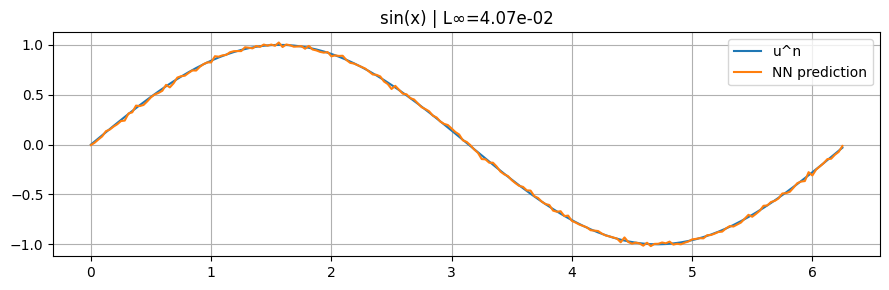

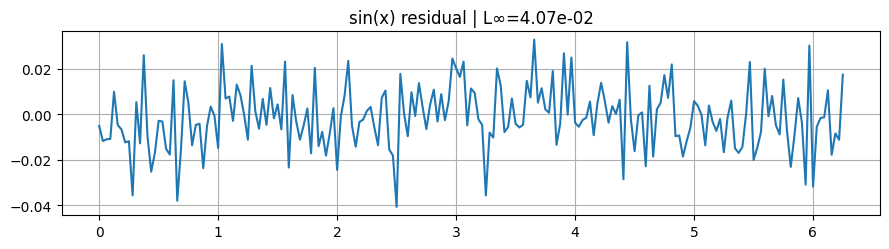

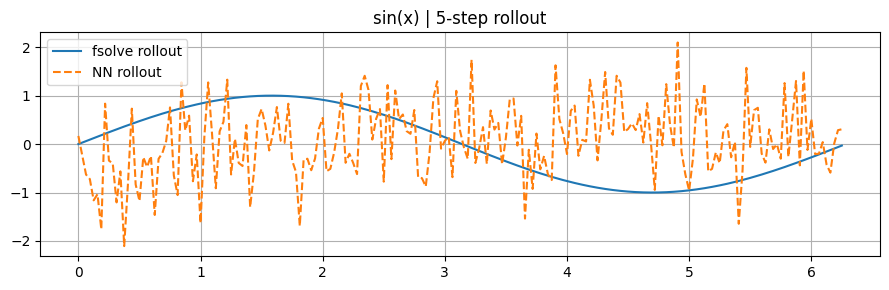


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=3.863e-02 | Mean=9.919e-03


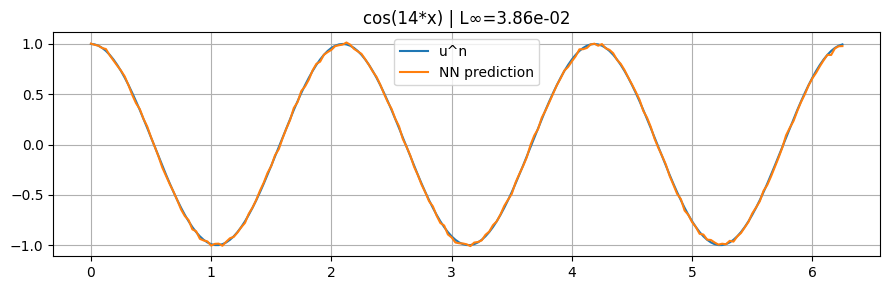

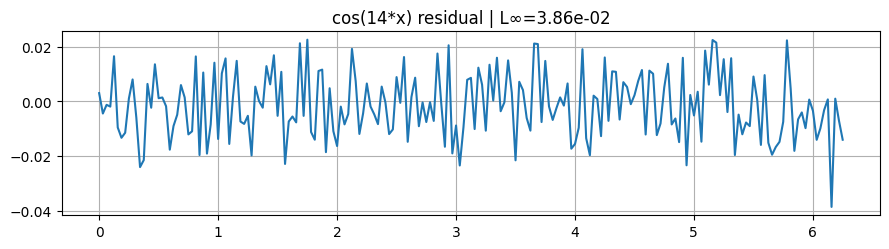

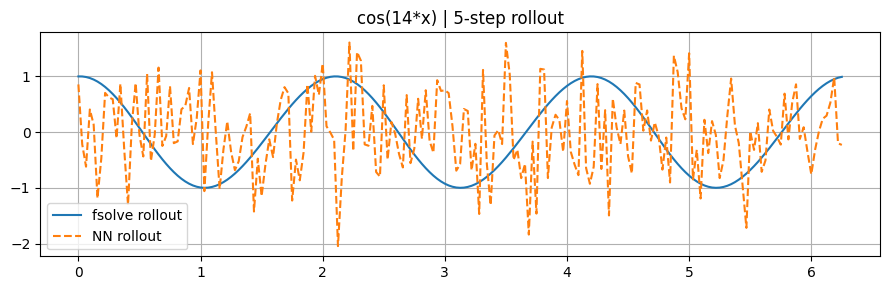


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=4.511e-02 | Mean=1.063e-02


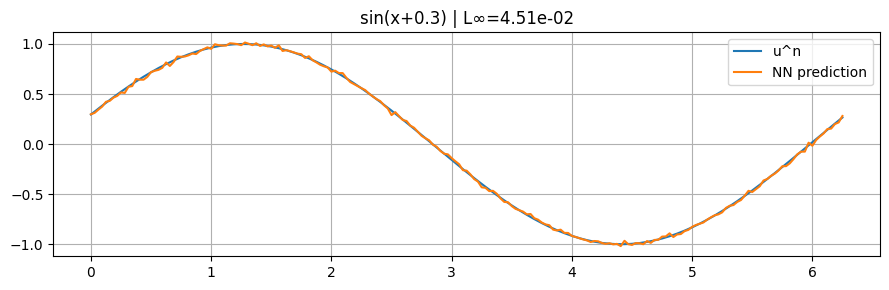

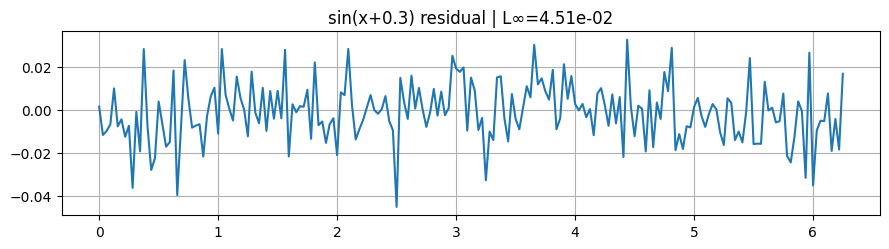

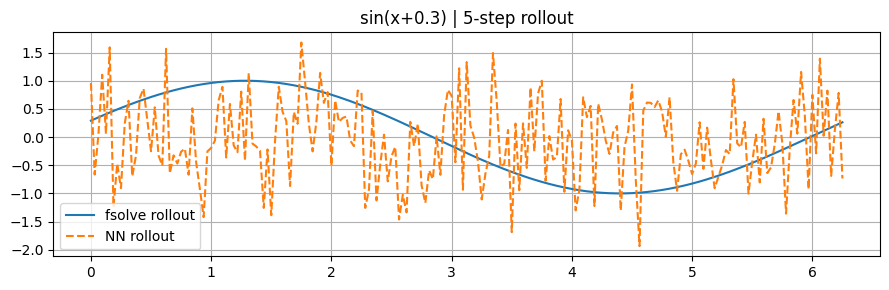


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=2.314e-02 | Mean=6.593e-03


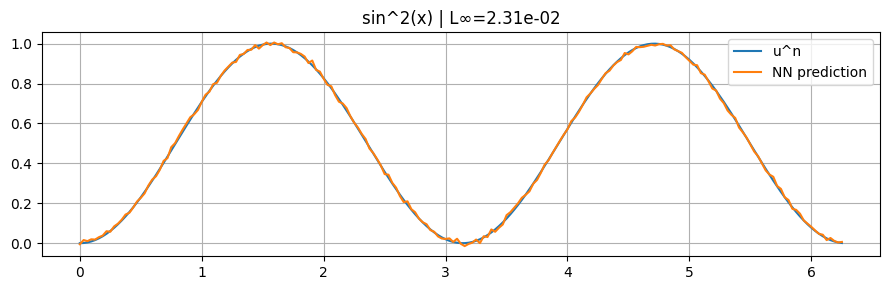

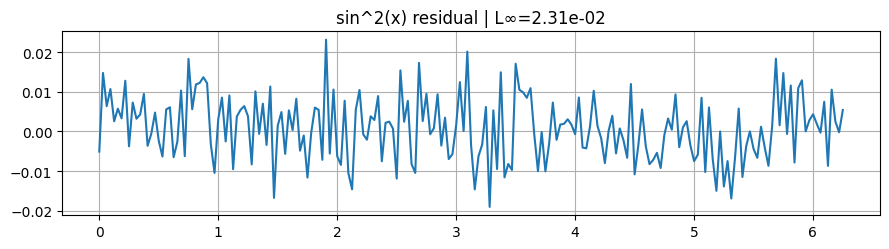

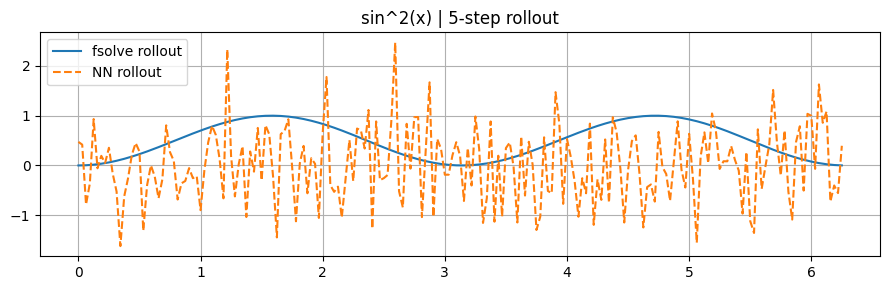


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=2.951e-02 | Mean=9.337e-03


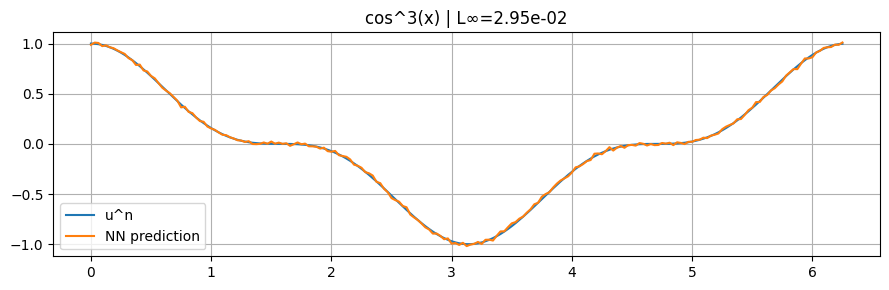

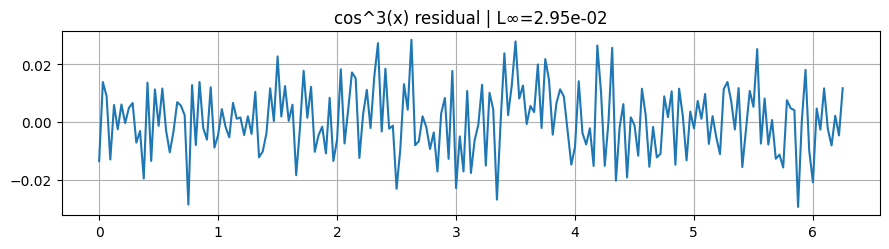

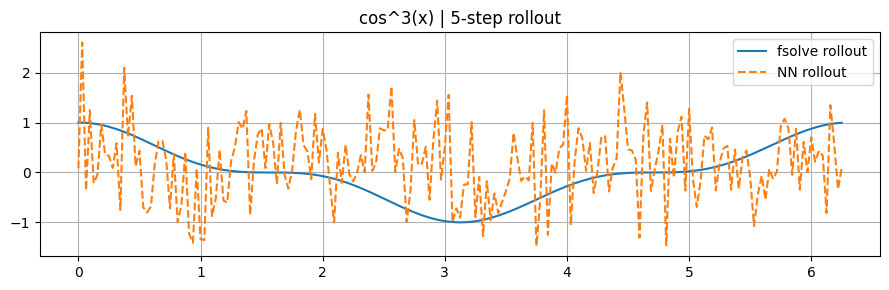


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=2.616e-02 | Mean=8.274e-03


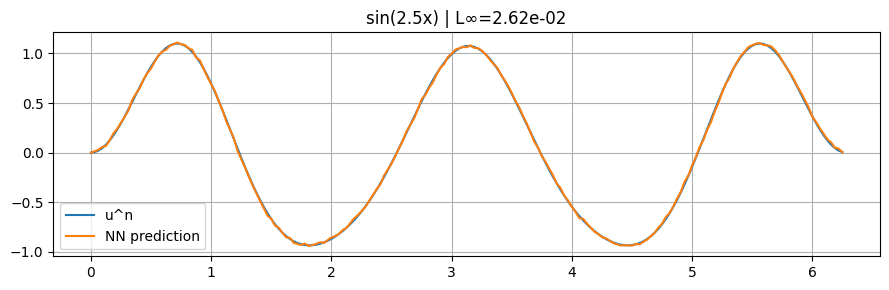

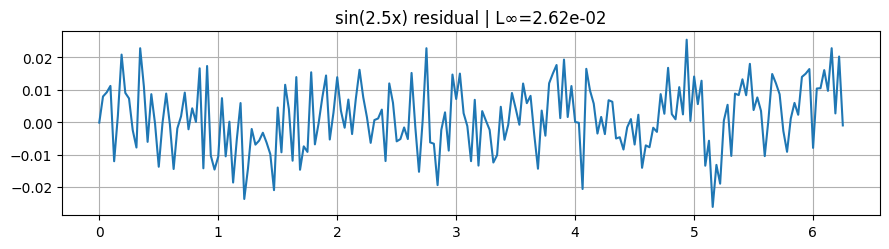

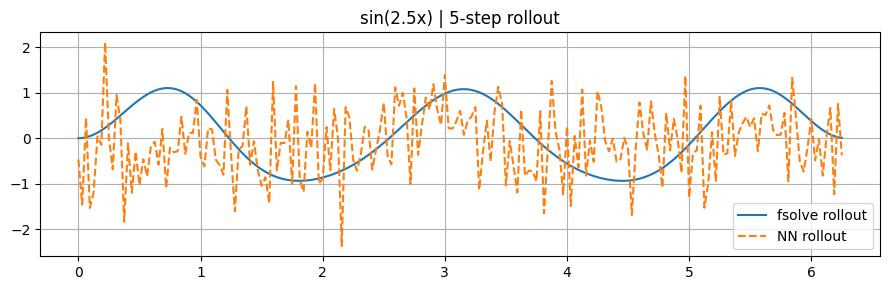


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=4.060e-02 | Mean=9.704e-03


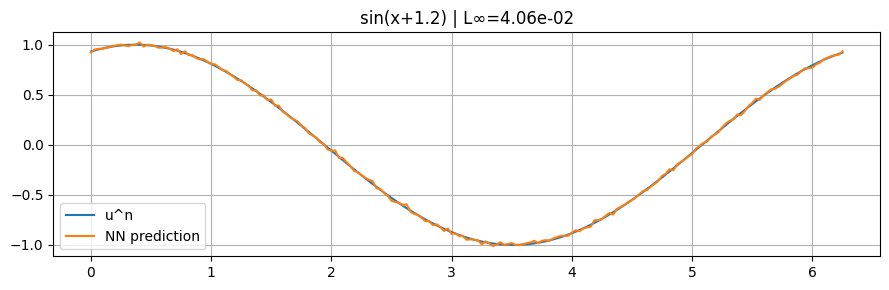

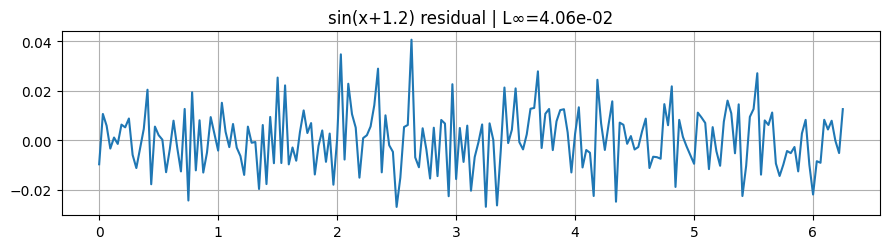

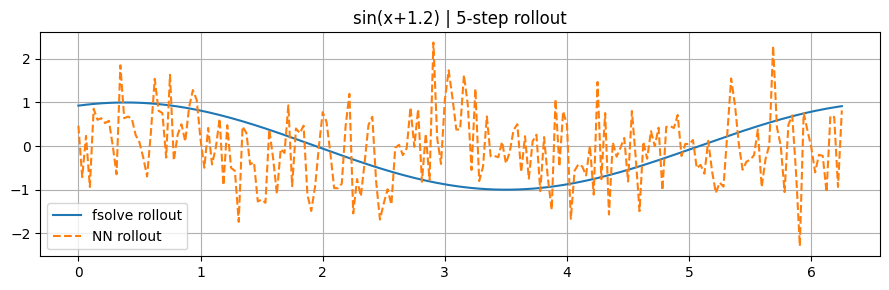


DONE.


In [5]:
# Physics only case
import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

# CONFIG
TF64 = True
NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

EPOCHS       = 1200
LR           = 2e-5

SUP_WEIGHT   = 0.0
PHYS_WEIGHT  = 0.1 / DT  

BETA_L2      = 1e-6
GRAD_CLIP    = 0.5
PATIENCE     = 800

USE_LBFGS        = True
LBFGS_MAXITER    = 300
LBFGS_FTOL       = 1e-10

OUT_DIR   = "pinn_caseB_phys_only"
os.makedirs(OUT_DIR, exist_ok=True)
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "nn_caseB.weights.h5")
DATA_FILE    = os.path.join(OUT_DIR, "train_pairs_caseB_v2.npz")  # FIX 2

if TF64:
    tf.keras.backend.set_floatx('float64')

np.random.seed(42); tf.random.set_seed(42); random.seed(42)

# Spectral differentiation
def generate_D_matrix(Nx, L):
    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)
    I = np.eye(Nx)
    return np.fft.ifft(k[:, None]*np.fft.fft(I, axis=0), axis=0).real

D_np = generate_D_matrix(NX_FINE, L)
D_tf = tf.constant(D_np, dtype=tf.float64)

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):
    y_sq = tf.square(y)
    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))
    return y - u + 0.25*DT*dy_dx

# grids
x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE,   endpoint=False)

def fourier_interpolate(u_coarse, Nc, Nf):
    Uc = np.fft.fftshift(np.fft.fft(u_coarse))
    pad = Nf - Nc
    Uc = np.pad(Uc, (pad//2, pad-pad//2))
    return (np.fft.ifft(np.fft.ifftshift(Uc))*Nf/Nc).real

# fsolve

def compute_y1_fsolve(un):
    def F(y): return y - un + 0.25*DT*(D_np @ (y**2))
    def J(y): return np.eye(len(un)) + 0.5*DT*(D_np @ np.diag(y))
    y,_ ,_,_=fsolve(F,un,fprime=J,full_output=True)
    return y

# Training Functions
def make_rich_family():
    fns = []
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]

    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns


train_fns = make_rich_family()

# DATA

if os.path.exists(DATA_FILE):
    d=np.load(DATA_FILE)
    un_train=d["un"]; y1_train=d["y1"]
else:
    U=[]; Y=[]
    for _,fn in train_fns:
        uc=fn(x_coarse)
        uf=fourier_interpolate(uc,NX_COARSE,NX_FINE)
        U.append(uf); Y.append(compute_y1_fsolve(uf))
    un_train=np.array(U)
    y1_train=np.array(Y)
    np.savez(DATA_FILE,un=un_train,y1=y1_train)

# FEATURES
def build_features(U):
    mag=np.abs(np.fft.fft(U,axis=-1))[:,:NX_FINE//2+1]
    mag = 0.2 * mag
    return np.concatenate([U,mag],axis=-1)

X_raw=build_features(un_train)
feat_mean=X_raw.mean(0)
feat_std=X_raw.std(0)+1e-12
X_norm=(X_raw-feat_mean)/feat_std

X_tf=tf.constant(X_norm,dtype=tf.float64)
U_tf=tf.constant(un_train,dtype=tf.float64)

# MODEL
class SineDense(tf.keras.layers.Layer):
    def __init__(self,units,w0=30,is_first=False):
        super().__init__(dtype=tf.float64)
        self.units=units; self.w0=w0; self.is_first=is_first
    def build(self,input_shape):
        d=int(input_shape[-1])
        b=(1/d) if self.is_first else np.sqrt(6/d)/self.w0
        self.W=self.add_weight(shape=(d,self.units),
            initializer=tf.random_uniform_initializer(-b,b),dtype=tf.float64)
        self.b=self.add_weight(shape=(self.units,),initializer="zeros",dtype=tf.float64)
    def call(self,x):
        return tf.sin(self.w0*(x@self.W+self.b))

def build_model():
    inp=tf.keras.Input(shape=(X_norm.shape[1],),dtype=tf.float64)
    h=SineDense(HIDDEN_UNITS,SIREN_W0,True)(inp)
    for _ in range(DEPTH-1):
        h=SineDense(HIDDEN_UNITS,SIREN_W0)(h)
    out=tf.keras.layers.Dense(NX_FINE,dtype=tf.float64)(h)
    return tf.keras.Model(inp,out)

model=build_model()
opt=tf.keras.optimizers.Adam(LR)


# TRAIN

print("\n PHASE 1: Physics-only ")

best=np.inf; wait=0

for ep in range(1,EPOCHS+1):
    with tf.GradientTape() as tape:
        y=model(X_tf,training=True)
        r=residual_tf(y,U_tf)
        phys=tf.reduce_mean(tf.square(r))
        reg=BETA_L2*tf.add_n([tf.nn.l2_loss(v) for v in model.trainable_variables])
        total=PHYS_WEIGHT*phys+reg   # FIXED

    grads=tape.gradient(total,model.trainable_variables)
    grads=[tf.clip_by_norm(g,GRAD_CLIP) for g in grads]
    opt.apply_gradients(zip(grads,model.trainable_variables))

    if ep%100==0 or ep==1:
        print(ep,"phys",float(phys))

    if total<best:
        best=float(total); wait=0
        model.save_weights(WEIGHTS_FILE)
    else:
        wait+=1
        if wait>PATIENCE: break


# TESTING

print("\n TEST & DIAGNOSTICS (Physics-only + rollout) ")

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64))[0].numpy()
        u = y.copy()
        traj.append(u.copy())
    return traj

tests = [
    ("sin(x)", lambda x: np.sin(x)),
    ("cos(14*x)", lambda x: np.cos(14*x)),
    ("sin(x+0.3)", lambda x: np.sin(x+0.3)),
    ("sin^2(x)", lambda x: np.sin(x)**2),
    ("cos^3(x)", lambda x: np.cos(x)**3),
    ("sin(2.5x)", lambda x: np.sin(2.5*x)),
    ("sin(x+1.2)", lambda x: np.sin(x+1.2))
]

for name, fn in tests:

    print("\n---", name, "---")

    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)
    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64))[0].numpy()

    # Physics residual
    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    # Solution plot
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Rollout
    traj_nn = rollout_nn(uf, 5)

    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(5):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")
    plt.title(f"{name} | 5-step rollout")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

print("\nDONE.")